In [1]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [2]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}


In [3]:
def extract_features(file_path):
    audio, sr = librosa.load(file_path, duration=3, offset=0.5)
    
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    
    delta = librosa.feature.delta(mfcc)
    delta_mean = np.mean(delta.T, axis=0)
    
    delta2 = librosa.feature.delta(mfcc, order=2)
    delta2_mean = np.mean(delta2.T, axis=0)
    
    return np.hstack([mfcc_mean, delta_mean, delta2_mean])


In [4]:
X = []
y = []

ravdess_path = "data/RAVDESS"

for actor in os.listdir(ravdess_path):
    actor_path = os.path.join(ravdess_path, actor)
    
    for file in os.listdir(actor_path):
        if file.endswith(".wav"):
            file_path = os.path.join(actor_path, file)
            
            features = extract_features(file_path)
            emotion_code = file.split("-")[2]
            emotion = emotion_map[emotion_code]
            
            X.append(features)
            y.append(emotion)

X = np.array(X)
y = np.array(y)

print("Total samples:", X.shape[0])
print("Feature vector size:", X.shape[1])


Total samples: 1439
Feature vector size: 120


In [5]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Reshape for CNN
X_train = X_train.reshape(X_train.shape[0], 120, 1)
X_test  = X_test.reshape(X_test.shape[0], 120, 1)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (1151, 120, 1)
X_test: (288, 120, 1)


In [6]:
model = Sequential()

model.add(Conv1D(64, 3, activation='relu', input_shape=(120,1)))
model.add(MaxPooling1D(2))
model.add(Dropout(0.3))

model.add(Conv1D(128, 3, activation='relu'))
model.add(MaxPooling1D(2))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(8, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


C:\Users\KIIT0001\speech_emotion_analyzer\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 118, 64)             │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 59, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 59, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 57, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 28, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 28, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3584)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         458,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 484,872 (1.85 MB)

 Trainable params: 484,872 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=80,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.1425 - loss: 3.4818 - val_accuracy: 0.2292 - val_loss: 2.0629 - learning_rate: 0.0010
Epoch 2/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.1546 - loss: 2.0965 - val_accuracy: 0.2049 - val_loss: 2.0521 - learning_rate: 0.0010
Epoch 3/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1668 - loss: 2.0622 - val_accuracy: 0.2188 - val_loss: 1.9754 - learning_rate: 0.0010
Epoch 4/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.1685 - loss: 2.0236 - val_accuracy: 0.2431 - val_loss: 1.9395 - learning_rate: 0.0010
Epoch 5/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2050 - loss: 1.9885 - val_accuracy: 0.2639 - val_loss: 1.9042 - learning_rate: 0.0010
Epoch 6/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.2207 - loss: 1.9783 - val_accuracy: 0.2639 - val_loss: 1.9006 - learning_rate: 0.0010
Epoch 7/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2354 - loss: 1.9233 - val_acc

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4583 - loss: 1.4312
Test Accuracy: 0.4583333432674408


In [9]:
model.save("speech_emotion_model.h5")
print("Model saved successfully")


Model saved successfully


In [10]:
model = load_model("speech_emotion_model.h5")
print("Model loaded successfully")


Model loaded successfully


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


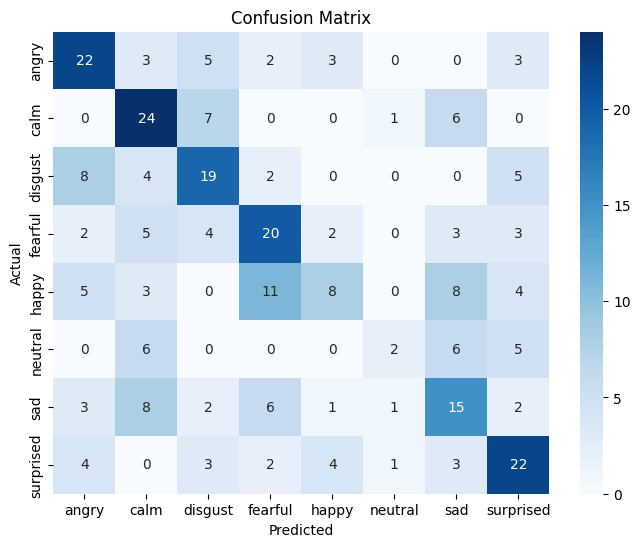

              precision    recall  f1-score   support

       angry       0.50      0.58      0.54        38
        calm       0.45      0.63      0.53        38
     disgust       0.47      0.50      0.49        38
     fearful       0.47      0.51      0.49        39
       happy       0.44      0.21      0.28        39
     neutral       0.40      0.11      0.17        19
         sad       0.37      0.39      0.38        38
   surprised       0.50      0.56      0.53        39

    accuracy                           0.46       288
   macro avg       0.45      0.44      0.42       288
weighted avg       0.45      0.46      0.44       288



In [11]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=label_encoder.classes_
))


In [12]:
model.save("artifacts/speech_emotion_model.h5")
print("Model saved successfully")


Model saved successfully


In [13]:
import numpy as np

np.save("artifacts/label_classes.npy", label_encoder.classes_)
print("Label classes saved")


Label classes saved


In [14]:
model.save("artifacts/speech_emotion_model.h5")
print("Model saved successfully")


Model saved successfully


In [15]:
import numpy as np

# Load saved label classes
label_classes = np.load("artifacts/label_classes.npy")

print("Label classes loaded:")
print(label_classes)


Label classes loaded:
['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [16]:
import librosa
import numpy as np

# Function to extract features (same as training)
def extract_features(file_path):
    audio, sr = librosa.load(file_path, duration=3, offset=0.5)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc_mean = np.mean(mfcc.T, axis=0)

    delta = librosa.feature.delta(mfcc)
    delta_mean = np.mean(delta.T, axis=0)

    delta2 = librosa.feature.delta(mfcc, order=2)
    delta2_mean = np.mean(delta2.T, axis=0)

    features = np.hstack([mfcc_mean, delta_mean, delta2_mean])
    return features

# Path to test audio file
test_audio_path = "data/RAVDESS/Actor_01/03-01-01-01-01-02-01.wav"

# Extract features
features = extract_features(test_audio_path)

print("Feature shape before reshape:", features.shape)


Feature shape before reshape: (120,)


In [17]:
# Reshape features for CNN input
features_reshaped = features.reshape(1, 120, 1)

# Predict emotion
prediction = model.predict(features_reshaped)

# Get predicted class index
predicted_index = np.argmax(prediction)

# Get emotion label
predicted_emotion = label_classes[predicted_index]

print("Predicted Emotion:", predicted_emotion)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
Predicted Emotion: sad
